# Analise do dataset IEMOCAP

Este notebook faz uma primeira analise exploratoria do IEMOCAP: quantidade de audios, duracao media, distribuicao por speaker, sessoes, dialogos e emocoes.

Antes de executar, ajuste `DATASET_ROOT` na primeira celula de codigo para apontar para a pasta raiz do IEMOCAP, aquela que contem `Session1`, `Session2`, etc.

In [1]:
from pathlib import Path

# Exemplo Windows: Path(r"D:\\datasets\\IEMOCAP_full_release")
# Exemplo Linux/Mac: Path("/data/IEMOCAP_full_release")
# Se deixar vazio, o notebook tenta achar uma pasta com Session1 dentro do diretorio atual.
DATASET_ROOT = Path(r"")

def looks_like_iemocap_root(path: Path) -> bool:
    return path.exists() and path.is_dir() and any((path / f"Session{i}").exists() for i in range(1, 6))

if str(DATASET_ROOT) in {"", "."}:
    candidates = [Path.cwd()]
    candidates.extend(p.parent for p in Path.cwd().rglob("Session1"))
    matches = [p for p in candidates if looks_like_iemocap_root(p)]
    if not matches:
        raise FileNotFoundError(
            "Nao encontrei a raiz do IEMOCAP automaticamente. "
            "Preencha DATASET_ROOT com a pasta que contem Session1..Session5."
        )
    root = matches[0]
else:
    root = DATASET_ROOT.expanduser().resolve()

if not looks_like_iemocap_root(root):
    raise FileNotFoundError(f"Este caminho nao parece ser a raiz do IEMOCAP: {root}")

root

WindowsPath('C:/Users/mateu/repos/test_speach_dataset')

## Coleta dos arquivos e metadados

O IEMOCAP normalmente guarda os audios de utterances em `Session*/sentences/wav/**.wav` e as avaliacoes emocionais em `Session*/dialog/EmoEvaluation/*.txt`.

In [2]:
import contextlib
import re
import wave

import numpy as np
import pandas as pd

def wav_duration_seconds(path: Path):
    try:
        with contextlib.closing(wave.open(str(path), "rb")) as wav:
            frames = wav.getnframes()
            rate = wav.getframerate()
            return frames / float(rate), rate, wav.getnchannels()
    except Exception as exc:
        return np.nan, np.nan, np.nan

def parse_session(path: Path):
    match = re.search(r"Session(\d+)", str(path))
    return int(match.group(1)) if match else np.nan

def parse_utterance_id(path: Path):
    return path.stem

def parse_speaker_from_utterance(utterance_id: str):
    # Ex.: Ses01F_impro01_F000 -> speaker_code=F; speaker_id=Ses01F
    match = re.match(r"Ses(?P<session>\d{2})(?P<speaker>[FM])_", utterance_id)
    if not match:
        return pd.Series({"speaker_code": None, "speaker_id": None})
    speaker_code = match.group("speaker")
    speaker_id = f"Ses{match.group('session')}{speaker_code}"
    return pd.Series({"speaker_code": speaker_code, "speaker_id": speaker_id})

wav_paths = sorted(root.glob("Session*/sentences/wav/**/*.wav"))
audio_rows = []
for path in wav_paths:
    duration, sample_rate, channels = wav_duration_seconds(path)
    audio_rows.append({
        "utterance_id": parse_utterance_id(path),
        "session": parse_session(path),
        "dialog_id": path.parent.name,
        "path": str(path),
        "duration_s": duration,
        "sample_rate": sample_rate,
        "channels": channels,
    })

audio_df = pd.DataFrame(audio_rows)
if not audio_df.empty:
    audio_df = pd.concat([audio_df, audio_df["utterance_id"].apply(parse_speaker_from_utterance)], axis=1)

audio_df.head()

,utterance_id,session,dialog_id,path,duration_s,sample_rate,channels,speaker_code,speaker_id
0,Ses01F_impro01_F000,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.945563,16000,1,F,Ses01F
1,Ses01F_impro01_F001,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.382437,16000,1,F,Ses01F
2,Ses01F_impro01_F002,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.130250,16000,1,F,Ses01F
3,Ses01F_impro01_F003,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.497500,16000,1,F,Ses01F
4,Ses01F_impro01_F004,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.414250,16000,1,F,Ses01F


In [3]:
emotion_re = re.compile(
    r"^\[(?P<start>[0-9.]+)\s*-\s*(?P<end>[0-9.]+)\]\s+"
    r"(?P<utterance_id>\S+)\s+(?P<emotion>\S+)\s+"
    r"\[(?P<valence>[0-9.]+),\s*(?P<activation>[0-9.]+),\s*(?P<dominance>[0-9.]+)\]"
)

emotion_rows = []
for path in sorted(root.glob("Session*/dialog/EmoEvaluation/*.txt")):
    session = parse_session(path)
    with path.open("r", encoding="latin-1") as f:
        for line in f:
            match = emotion_re.match(line.strip())
            if not match:
                continue
            row = match.groupdict()
            row.update({"session": session, "source_file": str(path)})
            emotion_rows.append(row)

emotion_df = pd.DataFrame(emotion_rows)
if not emotion_df.empty:
    numeric_cols = ["start", "end", "valence", "activation", "dominance"]
    emotion_df[numeric_cols] = emotion_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    emotion_df["label_duration_s"] = emotion_df["end"] - emotion_df["start"]
    emotion_df = pd.concat([emotion_df, emotion_df["utterance_id"].apply(parse_speaker_from_utterance)], axis=1)

emotion_df.head()

,start,end,utterance_id,emotion,valence,activation,dominance,session,source_file,label_duration_s,speaker_code,speaker_id
0,6.2901,8.2357,Ses01F_impro01_F000,neu,2.5,2.5,2.5,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.9456,F,Ses01F
1,10.0100,11.3925,Ses01F_impro01_F001,neu,2.5,2.5,2.5,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.3825,F,Ses01F
2,14.8872,18.0175,Ses01F_impro01_F002,neu,2.5,2.5,2.5,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.1303,F,Ses01F
3,19.2900,20.7875,Ses01F_impro01_F003,xxx,2.5,3.0,3.0,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.4975,F,Ses01F
4,21.3257,24.7400,Ses01F_impro01_F004,xxx,2.5,3.0,2.5,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.4143,F,Ses01F


In [4]:
transcript_re = re.compile(r"^(?P<utterance_id>\S+)\s+\[(?P<start>[0-9.]+)\s*-\s*(?P<end>[0-9.]+)\]:\s*(?P<text>.*)$")

transcript_rows = []
for path in sorted(root.glob("Session*/dialog/transcriptions/*.txt")):
    session = parse_session(path)
    with path.open("r", encoding="latin-1") as f:
        for line in f:
            match = transcript_re.match(line.strip())
            if not match:
                continue
            row = match.groupdict()
            row.update({"session": session, "source_file": str(path)})
            transcript_rows.append(row)

transcript_df = pd.DataFrame(transcript_rows)
if not transcript_df.empty:
    transcript_df[["start", "end"]] = transcript_df[["start", "end"]].apply(pd.to_numeric, errors="coerce")
    transcript_df["n_words"] = transcript_df["text"].str.split().str.len()

transcript_df.head()

,utterance_id,start,end,text,session,source_file,n_words
0,Ses01F_impro01_F000,6.2901,8.2357,Excuse me.,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,2
1,Ses01F_impro01_M000,7.5712,10.4750,Do you have your forms?,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,5
2,Ses01F_impro01_F001,10.0100,11.3925,Yeah.,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1
3,Ses01F_impro01_M001,10.9266,14.6649,Let me see them.,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,4
4,Ses01F_impro01_F002,14.8872,18.0175,Is there a problem?,1,C:\Users\mateu\repos\test_speach_dataset\Sessi...,4


## Tabela consolidada

A tabela abaixo junta audio, emocao e transcricao pelo `utterance_id`. Se algum campo vier vazio, isso normalmente indica arquivo faltando, estrutura diferente, ou utterances sem avaliacao.

In [5]:
df = audio_df.copy()

if not emotion_df.empty:
    df = df.merge(
        emotion_df[["utterance_id", "emotion", "valence", "activation", "dominance", "label_duration_s"]],
        on="utterance_id",
        how="left",
    )

if not transcript_df.empty:
    df = df.merge(
        transcript_df[["utterance_id", "text", "n_words"]],
        on="utterance_id",
        how="left",
    )

df.head()

,utterance_id,session,dialog_id,path,duration_s,sample_rate,channels,speaker_code,speaker_id,emotion,valence,activation,dominance,label_duration_s,text,n_words
0,Ses01F_impro01_F000,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.945563,16000,1,F,Ses01F,neu,2.5,2.5,2.5,1.9456,Excuse me.,2
1,Ses01F_impro01_F001,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.382437,16000,1,F,Ses01F,neu,2.5,2.5,2.5,1.3825,Yeah.,1
2,Ses01F_impro01_F002,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.130250,16000,1,F,Ses01F,neu,2.5,2.5,2.5,3.1303,Is there a problem?,4
3,Ses01F_impro01_F003,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,1.497500,16000,1,F,Ses01F,xxx,2.5,3.0,3.0,1.4975,You did.,2
4,Ses01F_impro01_F004,1,Ses01F_impro01,C:\Users\mateu\repos\test_speach_dataset\Sessi...,3.414250,16000,1,F,Ses01F,xxx,2.5,3.0,2.5,3.4143,You were standing at the beginning and you dir...,10


## Resumo geral

In [6]:
summary = pd.Series({
    "n_utterances_audio": len(audio_df),
    "n_utterances_com_emocao": int(df["emotion"].notna().sum()) if "emotion" in df else 0,
    "n_sessoes": int(df["session"].nunique()) if not df.empty else 0,
    "n_dialogos": int(df["dialog_id"].nunique()) if "dialog_id" in df else 0,
    "n_speakers": int(df["speaker_id"].nunique()) if "speaker_id" in df else 0,
    "tem_mais_de_um_speaker": bool(df["speaker_id"].nunique() > 1) if "speaker_id" in df else False,
    "duracao_total_horas": df["duration_s"].sum() / 3600 if "duration_s" in df else np.nan,
    "duracao_media_s": df["duration_s"].mean() if "duration_s" in df else np.nan,
    "duracao_mediana_s": df["duration_s"].median() if "duration_s" in df else np.nan,
    "duracao_min_s": df["duration_s"].min() if "duration_s" in df else np.nan,
    "duracao_max_s": df["duration_s"].max() if "duration_s" in df else np.nan,
})

summary

n_utterances_audio             10039
n_utterances_com_emocao        10039
n_sessoes                          5
n_dialogos                       151
n_speakers                        10
tem_mais_de_um_speaker          True
duracao_total_horas        12.437423
duracao_media_s             4.460078
duracao_mediana_s           3.519938
duracao_min_s               0.584937
duracao_max_s               34.13875
dtype: object

In [7]:
duration_desc = df["duration_s"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("duration_s")
duration_desc

,duration_s
count,10039.000000
mean,4.460078
std,3.064676
min,0.584937
5%,1.389938
25%,2.330000
50%,3.519938
75%,5.709937
95%,10.530244
max,34.138750


## Speakers e sessoes

In [8]:
speaker_summary = (
    df.groupby(["session", "speaker_id", "speaker_code"], dropna=False)
      .agg(
          n_utterances=("utterance_id", "count"),
          total_min=("duration_s", lambda x: x.sum() / 60),
          mean_duration_s=("duration_s", "mean"),
      )
      .reset_index()
      .sort_values(["session", "speaker_id"])
)

speaker_summary

,session,speaker_id,speaker_code,n_utterances,total_min,mean_duration_s
0,1,Ses01F,F,861,67.718139,4.719034
1,1,Ses01M,M,958,71.596335,4.484113
2,2,Ses02F,F,889,68.497299,4.622990
3,2,Ses02M,M,922,67.705295,4.405984
4,3,Ses03F,F,958,70.063695,4.388123
5,3,Ses03M,M,1178,87.589646,4.461272
6,4,Ses04F,F,1105,78.262839,4.249566
7,4,Ses04M,M,998,76.414849,4.594079
8,5,Ses05F,F,1128,80.518654,4.282907
9,5,Ses05M,M,1042,77.878651,4.484375


In [9]:
session_summary = (
    df.groupby("session", dropna=False)
      .agg(
          n_utterances=("utterance_id", "count"),
          n_speakers=("speaker_id", "nunique"),
          n_dialogs=("dialog_id", "nunique"),
          total_min=("duration_s", lambda x: x.sum() / 60),
          mean_duration_s=("duration_s", "mean"),
      )
      .reset_index()
)

session_summary

,session,n_utterances,n_speakers,n_dialogs,total_min,mean_duration_s
0,1,1819,2,28,139.314474,4.595310
1,2,1811,2,30,136.202594,4.512510
2,3,2136,2,32,157.653341,4.428465
3,4,2103,2,30,154.677688,4.413058
4,5,2170,2,31,158.397305,4.379649


## Emocoes

In [10]:
if "emotion" in df:
    emotion_summary = (
        df.groupby("emotion", dropna=False)
          .agg(
              n_utterances=("utterance_id", "count"),
              total_min=("duration_s", lambda x: x.sum() / 60),
              mean_duration_s=("duration_s", "mean"),
              mean_valence=("valence", "mean"),
              mean_activation=("activation", "mean"),
              mean_dominance=("dominance", "mean"),
          )
          .reset_index()
          .sort_values("n_utterances", ascending=False)
    )
else:
    emotion_summary = pd.DataFrame()

emotion_summary

,emotion,n_utterances,total_min,mean_duration_s,mean_valence,mean_activation,mean_dominance
10,xxx,2507,174.059191,4.165756,2.875415,3.038858,3.182057
4,fru,1849,145.155591,4.710295,2.262394,3.184874,3.321706
6,neu,1708,111.075622,3.901954,2.971361,2.725752,2.830553
0,ang,1103,82.962840,4.512938,1.905712,3.635539,3.949834
8,sad,1084,99.302221,5.496433,2.253075,2.563499,2.827952
2,exc,1041,82.948634,4.780901,3.945085,3.578370,3.402578
5,hap,595,43.051273,4.341305,3.951260,3.118488,2.923809
9,sur,107,5.544060,3.108819,2.845015,3.217290,2.854362
3,fea,40,1.817275,2.725913,2.504165,3.241665,2.366668
7,oth,3,0.250528,5.010562,3.277800,2.611133,2.166667


In [11]:
emotion_by_speaker = pd.crosstab(df["speaker_id"], df["emotion"], margins=True) if "emotion" in df else pd.DataFrame()
emotion_by_speaker

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx,All
speaker_id,,,,,,,,,,,,
Ses01F,97,1,40,7,144,77,226,1,67,12,189,861
Ses01M,132,0,103,5,136,58,158,0,127,13,226,958
Ses02F,65,0,99,3,158,49,209,1,83,9,213,889
Ses02M,72,0,111,6,167,68,153,0,114,8,223,922
Ses03F,88,0,77,2,153,68,156,0,147,12,255,958
Ses03M,152,1,74,0,229,67,164,0,158,16,317,1178
Ses04F,177,0,149,2,220,25,128,0,74,9,321,1105
Ses04M,150,0,89,5,261,40,130,1,69,10,243,998
Ses05F,78,0,164,2,208,72,192,0,138,6,268,1128


## Visualizacoes rapidas

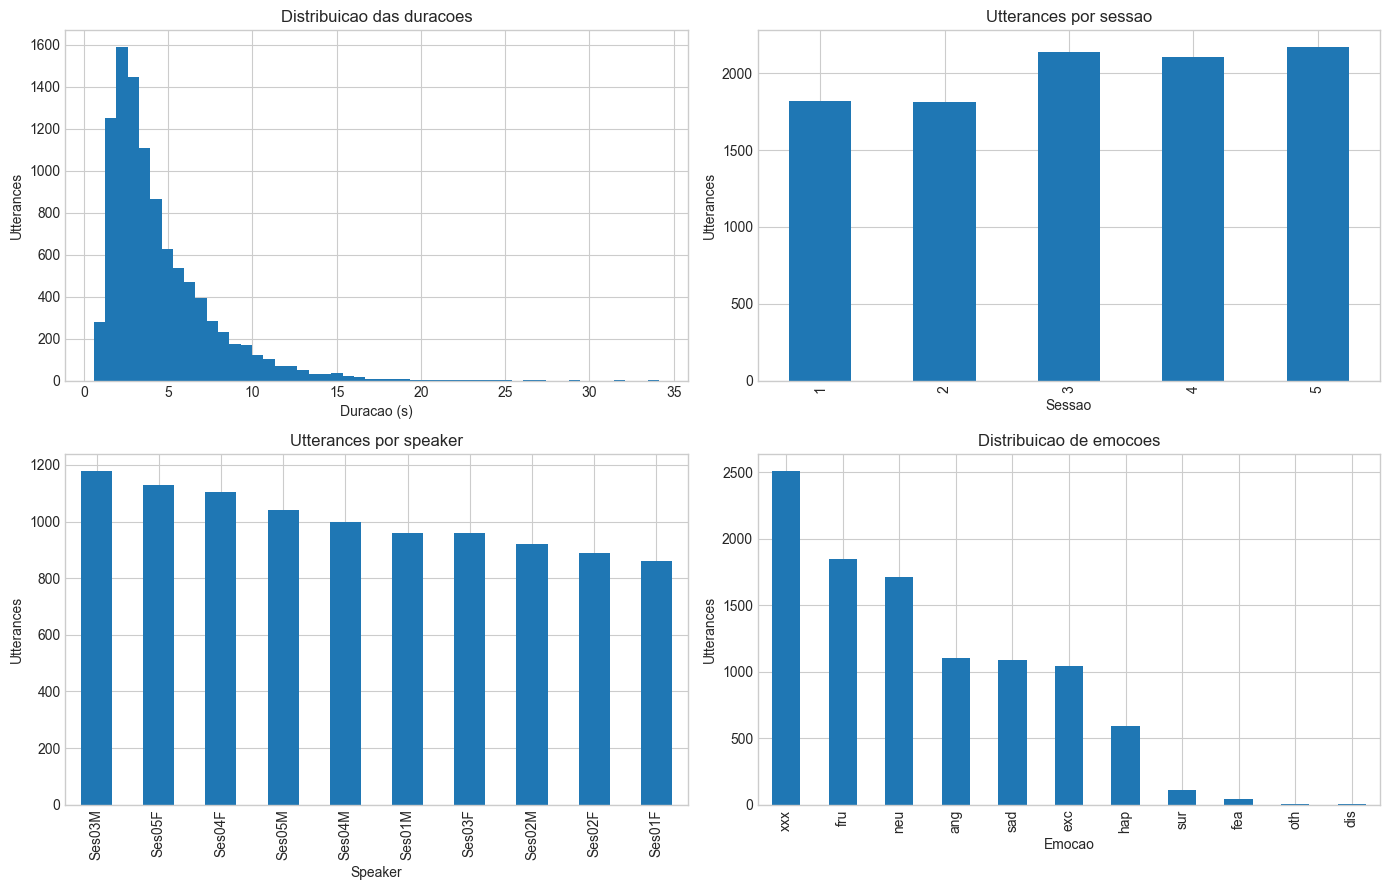

In [12]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df["duration_s"].dropna().hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribuicao das duracoes")
axes[0, 0].set_xlabel("Duracao (s)")
axes[0, 0].set_ylabel("Utterances")

df.groupby("session")["utterance_id"].count().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Utterances por sessao")
axes[0, 1].set_xlabel("Sessao")
axes[0, 1].set_ylabel("Utterances")

df.groupby("speaker_id")["utterance_id"].count().sort_values(ascending=False).plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Utterances por speaker")
axes[1, 0].set_xlabel("Speaker")
axes[1, 0].set_ylabel("Utterances")

if "emotion" in df and df["emotion"].notna().any():
    df["emotion"].value_counts().plot(kind="bar", ax=axes[1, 1])
    axes[1, 1].set_title("Distribuicao de emocoes")
    axes[1, 1].set_xlabel("Emocao")
    axes[1, 1].set_ylabel("Utterances")
else:
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## Observacoes automaticas

Esta celula transforma os principais numeros em texto para facilitar o relatorio.

In [13]:
n_speakers = df["speaker_id"].nunique() if "speaker_id" in df else 0
mean_duration = df["duration_s"].mean() if "duration_s" in df else np.nan
median_duration = df["duration_s"].median() if "duration_s" in df else np.nan
total_hours = df["duration_s"].sum() / 3600 if "duration_s" in df else np.nan

print(f"Foram encontrados {len(df):,} audios/utterances.".replace(",", "."))
print(f"Duracao media: {mean_duration:.2f}s; mediana: {median_duration:.2f}s; total: {total_hours:.2f}h.")
print(f"Numero de speakers inferidos: {n_speakers}.")
print("Ha mais de um speaker?", "sim" if n_speakers > 1 else "nao")

if "emotion" in df and df["emotion"].notna().any():
    top_emotion = df["emotion"].value_counts().idxmax()
    top_count = df["emotion"].value_counts().max()
    print(f"Emocao mais frequente: {top_emotion} ({top_count} utterances).")

if n_speakers > 0:
    print("Speakers encontrados:", ", ".join(sorted(df["speaker_id"].dropna().unique())))

Foram encontrados 10.039 audios/utterances.
Duracao media: 4.46s; mediana: 3.52s; total: 12.44h.
Numero de speakers inferidos: 10.
Ha mais de um speaker? sim
Emocao mais frequente: xxx (2507 utterances).
Speakers encontrados: Ses01F, Ses01M, Ses02F, Ses02M, Ses03F, Ses03M, Ses04F, Ses04M, Ses05F, Ses05M


## Export opcional

Descomente a linha abaixo se quiser salvar a tabela consolidada em CSV.

In [14]:
# df.to_csv("iemocap_consolidated_metadata.csv", index=False)